In [1]:
import pandas as pd

df = pd.read_hdf(
    "metr-la.h5",
    key="df"
)

data = df.values

print(data.shape)

(34272, 207)


In [2]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(data)

print(data_scaled.shape)

(34272, 207)


In [3]:
import numpy as np

SEQ_LEN = 12

X = []
y = []

for i in range(len(data_scaled)-SEQ_LEN):

    X.append(
        data_scaled[i:i+SEQ_LEN]
    )

    y.append(
        data_scaled[i+SEQ_LEN]
    )


X = np.array(X)
y = np.array(y)


print(X.shape)
print(y.shape)

(34260, 12, 207)
(34260, 207)


In [4]:
train_size = int(len(X)*0.7)
val_size = int(len(X)*0.1)


X_train = X[:train_size]
y_train = y[:train_size]


X_val = X[
    train_size:
    train_size+val_size
]

y_val = y[
    train_size:
    train_size+val_size
]


X_test = X[
    train_size+val_size:
]

y_test = y[
    train_size+val_size:
]


print(X_train.shape)
print(X_test.shape)

(23982, 12, 207)
(6852, 12, 207)


In [5]:
import torch

X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)


X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)

In [6]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader


train_dataset = TensorDataset(
    X_train,
    y_train
)


train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=False
)

In [7]:
import pickle

with open("adj_mx.pkl", "rb") as f:
    sensor_ids, sensor_id_to_ind, adj_mx = pickle.load(
        f,
        encoding="latin1"
    )

print(type(adj_mx))
print(adj_mx.shape)

<class 'numpy.ndarray'>
(207, 207)


In [8]:
print("Min:", adj_mx.min())
print("Max:", adj_mx.max())

print("Connections:")
print((adj_mx > 0).sum())

Min: 0.0
Max: 1.0
Connections:
1722


In [9]:
import numpy as np

A = adj_mx

# add self connections
A = A + np.eye(A.shape[0])


degree = np.sum(A, axis=1)

D_inv_sqrt = np.diag(
    np.power(degree, -0.5)
)

A_hat = (
    D_inv_sqrt
    @ A
    @ D_inv_sqrt
)

print(A_hat.shape)

(207, 207)


In [10]:
import torch

A_hat = torch.FloatTensor(A_hat)

In [11]:
import torch.nn as nn


class TemporalConv(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=(3,1),
            padding=(1,0)
        )


    def forward(self,x):

        return torch.relu(
            self.conv(x)
        )

In [12]:
class AttentionGraphConv(nn.Module):

    def __init__(self, channels):

        super().__init__()

        self.weight = nn.Linear(
            channels,
            channels
        )

        self.attn = nn.Linear(
            channels,
            channels
        )

    def forward(self,x,A):

        x = torch.einsum(
            "ij,bctj->bcti",
            A,
            x
        )

        x = x.permute(
            0,2,3,1
        )

        features = self.weight(x)

        attention = torch.sigmoid(
            self.attn(x)
        )

        x = features * attention

        x = x.permute(
            0,3,1,2
        )

        return torch.relu(x)

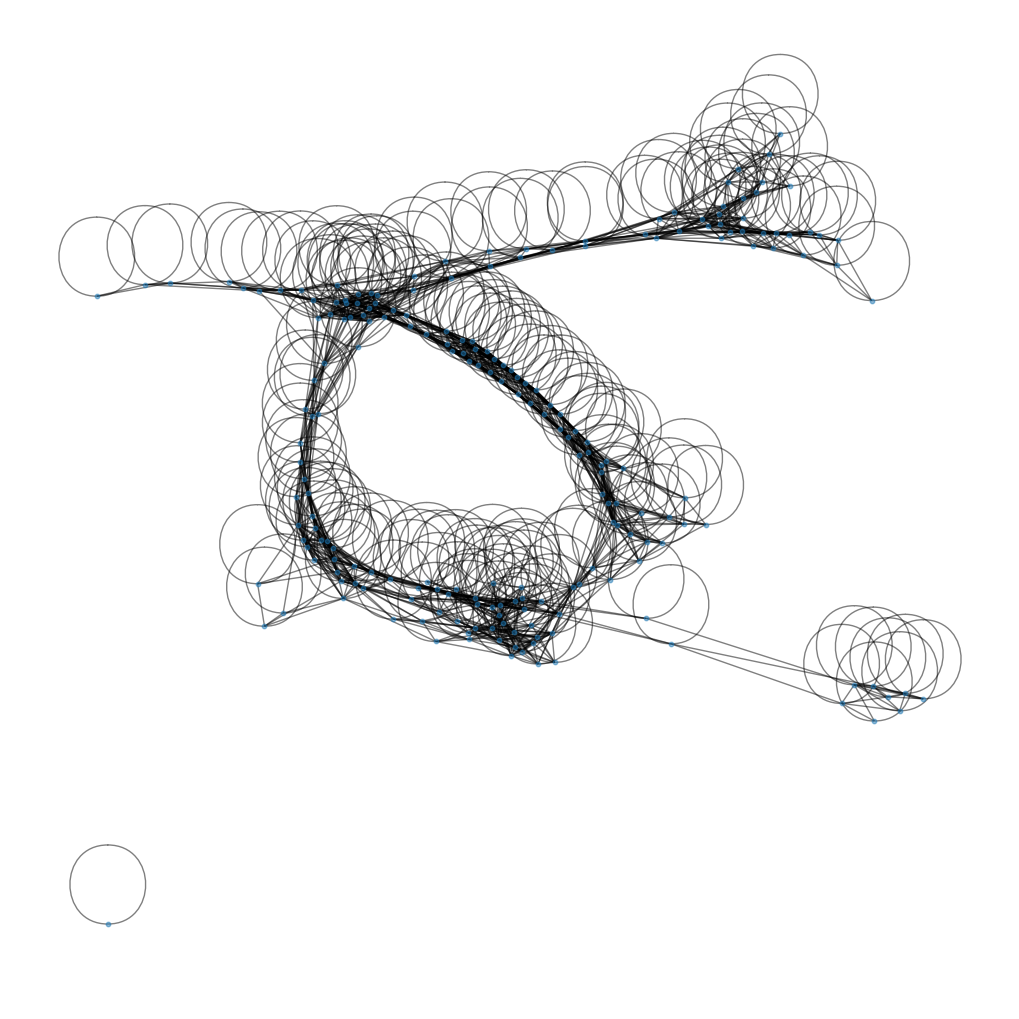

In [13]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.from_numpy_array(adj_mx)

plt.figure(figsize=(10,10))
nx.draw(
    G,
    node_size=10,
    alpha=0.5
)

plt.show()

In [14]:
class STGCN(nn.Module):

    def __init__(self):

        super().__init__()


        self.temp1 = TemporalConv(
            1,
            32
        )


        self.graph = AttentionGraphConv(
            32
        )


        self.temp2 = TemporalConv(
            32,
            32
        )


        self.fc = nn.Linear(
            32,
            1
        )


    def forward(self,x):

        # x:
        # batch,12,207


        x = x.unsqueeze(1)

        # batch,1,12,207


        x = self.temp1(x)

        x = self.graph(
            x,
            A_hat
        )


        x = self.temp2(x)


        # average time dimension

        x = x.mean(dim=2)


        # batch,32,207


        x = x.permute(
            0,2,1
        )


        x = self.fc(x)

        x = x.squeeze(-1)

        return x

In [15]:
model = STGCN()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [16]:
epochs = 30

for epoch in range(epochs):

    model.train()

    total_loss = 0


    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()


        predictions = model(
            X_batch
        )


        loss = criterion(
            predictions,
            y_batch
        )


        loss.backward()


        optimizer.step()


        total_loss += loss.item()


    avg_loss = total_loss / len(train_loader)


    print(
        f"Epoch {epoch+1}/{epochs} "
        f"Loss: {avg_loss:.6f}"
    )

Epoch 1/30 Loss: 0.084607
Epoch 2/30 Loss: 0.026688
Epoch 3/30 Loss: 0.024539
Epoch 4/30 Loss: 0.021735
Epoch 5/30 Loss: 0.019659
Epoch 6/30 Loss: 0.018112
Epoch 7/30 Loss: 0.016726
Epoch 8/30 Loss: 0.015945
Epoch 9/30 Loss: 0.015475
Epoch 10/30 Loss: 0.015177
Epoch 11/30 Loss: 0.014984
Epoch 12/30 Loss: 0.014738
Epoch 13/30 Loss: 0.014620
Epoch 14/30 Loss: 0.014545
Epoch 15/30 Loss: 0.014371
Epoch 16/30 Loss: 0.014271
Epoch 17/30 Loss: 0.014137
Epoch 18/30 Loss: 0.013999
Epoch 19/30 Loss: 0.013884
Epoch 20/30 Loss: 0.013783
Epoch 21/30 Loss: 0.013678
Epoch 22/30 Loss: 0.013668
Epoch 23/30 Loss: 0.013479
Epoch 24/30 Loss: 0.013411
Epoch 25/30 Loss: 0.013337
Epoch 26/30 Loss: 0.013274
Epoch 27/30 Loss: 0.013209
Epoch 28/30 Loss: 0.013156
Epoch 29/30 Loss: 0.013105
Epoch 30/30 Loss: 0.013045


In [17]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np


model.eval()


with torch.no_grad():

    predictions = model(
        X_test
    )


predictions = predictions.numpy()

true_values = y_test.numpy()


mae = mean_absolute_error(
    true_values,
    predictions
)


rmse = np.sqrt(
    mean_squared_error(
        true_values,
        predictions
    )
)


print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.066929124
RMSE: 0.12037082
